# Credit Card Default Prediction Using Machine Learning

## Problem Statement

The objective of this project is to predict whether a credit card customer will default on their payment using machine learning classification models.

The target variable is Y:

- 0 → No Default
- 1 → Default

## Dataset Description

The dataset contains information about credit card customers, including demographic details, credit limit, repayment status, bill amounts, and payment amounts.

The target variable Y represents whether the customer defaulted on the next month's payment.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


## Data Loading

The credit card default dataset is loaded using Pandas for further analysis and preprocessing.

In [43]:
df = pd.read_csv("default of credit card clients.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (30001, 25)


## Initial Dataset Inspection

The dataset is inspected to understand its structure, feature types, missing values, duplicate records, and target variable distribution.

In [44]:
print("First 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

First 5 rows:


,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0



Column names:
['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'Y']

Data types:
Unnamed: 0    str
X1            str
X2            str
X3            str
X4            str
X5            str
X6            str
X7            str
X8            str
X9            str
X10           str
X11           str
X12           str
X13           str
X14           str
X15           str
X16           str
X17           str
X18           str
X19           str
X20           str
X21           str
X22           str
X23           str
Y             str
dtype: object

Missing values:
Unnamed: 0    0
X1            0
X2            0
X3            0
X4            0
X5            0
X6            0
X7            0
X8            0
X9            0
X10           0
X11           0
X12           0
X13           0
X14           0
X15           0
X16           0
X17           0
X18           0
X19           0

### Data Cleaning

The dataset contains an additional header row within the data. This row is removed and the remaining values are converted to numeric format. Duplicate rows are checked and removed to avoid repeated observations affecting model training and evaluation.


In [45]:
# Remove the extra header row
df = df.iloc[1:].copy()
df = df.drop(columns=["Unnamed: 0"])

# Convert all columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)

print("\nTotal missing values:", df.isnull().sum().sum())

# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Cleaned dataset shape: (30000, 24)

Total missing values: 0
Duplicate rows: 35
Shape after removing duplicates: (29965, 24)


## Target Variable Distribution

The target variable Y represents credit card payment default. Class 0 represents no default, while class 1 represents default.

Target distribution:
Y
0    23335
1     6630
Name: count, dtype: int64


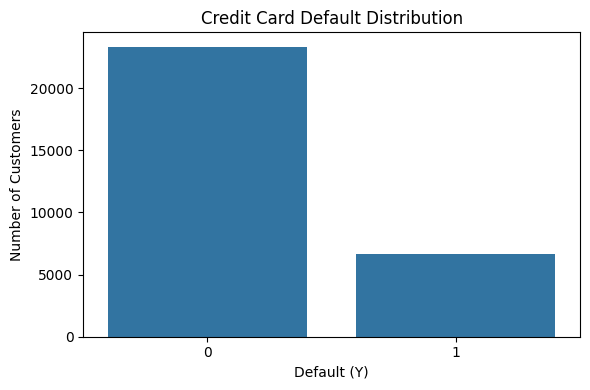

In [46]:
print("Target distribution:")
print(df["Y"].value_counts())

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Y")

plt.title("Credit Card Default Distribution")
plt.xlabel("Default (Y)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Observation

The target variable contains two classes, 0 and 1. The distribution shows that the non-default class contains more customers than the default class, indicating class imbalance in the dataset.

## Descriptive Statistics

Descriptive statistics are used to understand the central tendency, spread, and range of the numerical features.

In [47]:
display(df.describe())

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
count,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,...,29965.000000,29965.000000,29965.000000,29965.000000,2.996500e+04,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000
mean,167442.005006,1.603738,1.853629,1.551877,35.487969,-0.016753,-0.131854,-0.164392,-0.218922,-0.264509,...,43313.329885,40358.334390,38917.012281,5670.099316,5.927983e+03,5231.688837,4831.617454,4804.897047,5221.498014,0.221258
std,129760.135222,0.489128,0.790411,0.521997,9.219459,1.123492,1.196322,1.195878,1.168175,1.132220,...,64353.514373,60817.130623,59574.147742,16571.849467,2.305346e+04,17616.361124,15674.464538,15286.372298,17786.976864,0.415101
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2360.000000,1787.000000,1262.000000,1000.000000,8.500000e+02,390.000000,300.000000,261.000000,131.000000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19081.000000,18130.000000,17124.000000,2102.000000,2.010000e+03,1804.000000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54601.000000,50247.000000,49252.000000,5008.000000,5.000000e+03,4512.000000,4016.000000,4042.000000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,528666.000000,1.000000


## Feature Distribution Analysis

Distribution plots are used to examine the spread and shape of the features in the dataset.

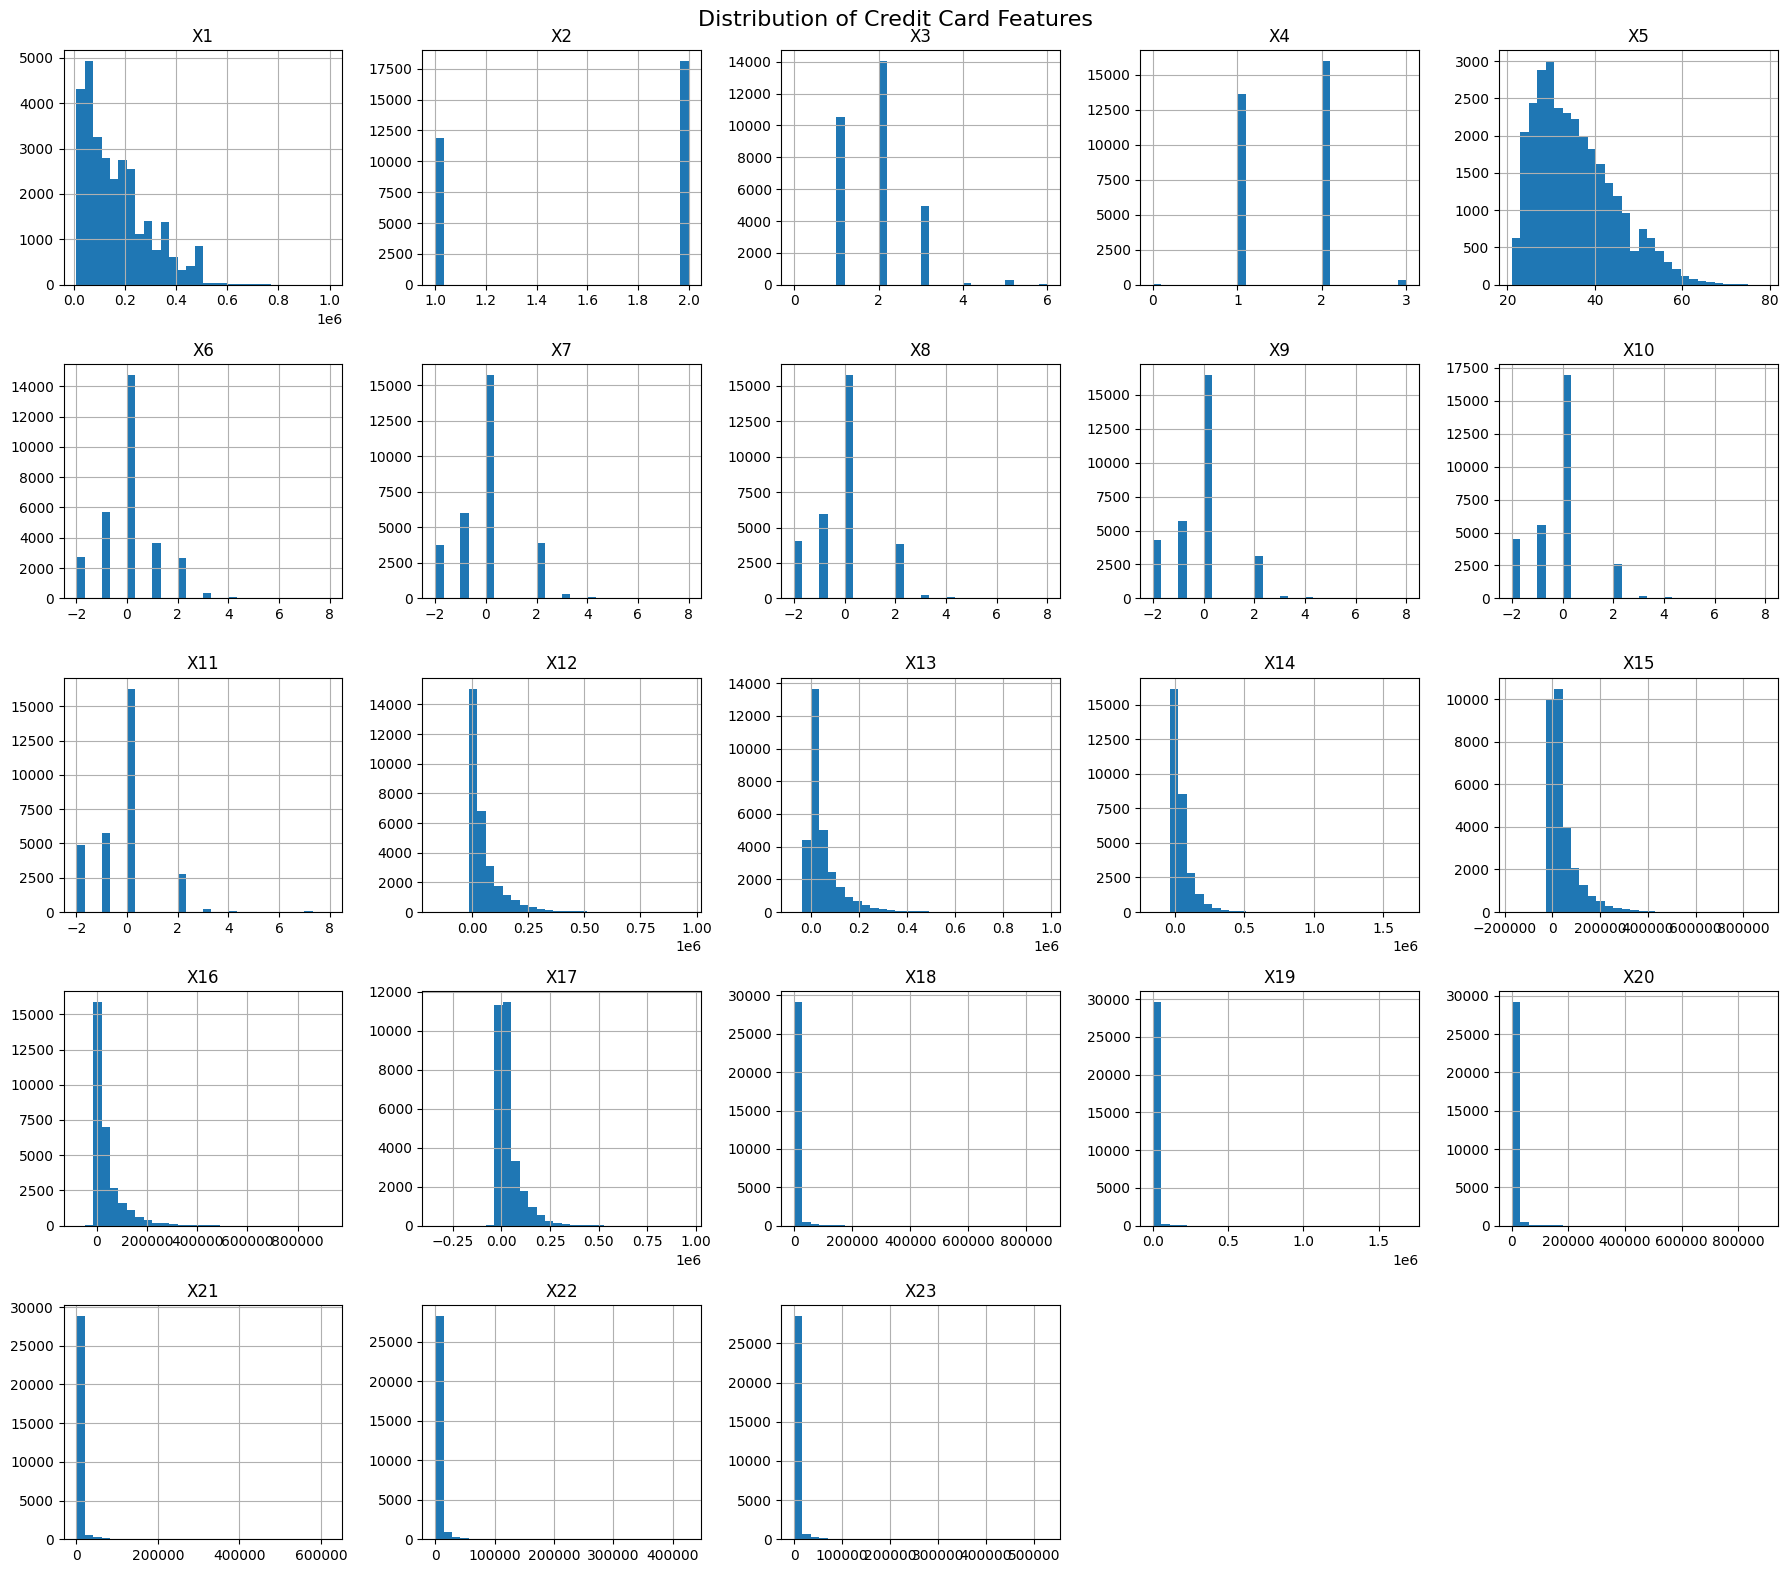

In [48]:
features = df.drop(columns=["Y"]).columns

df[features].hist(
    figsize=(18, 16),
    bins=30
)

plt.suptitle("Distribution of Credit Card Features", fontsize=16)
plt.tight_layout()
plt.show()

### Observation

The feature distributions have different ranges and shapes. Several financial variables show skewed distributions and extreme values, which require further outlier analysis before model training.

## Correlation Analysis

A correlation heatmap is used to examine relationships between numerical features.

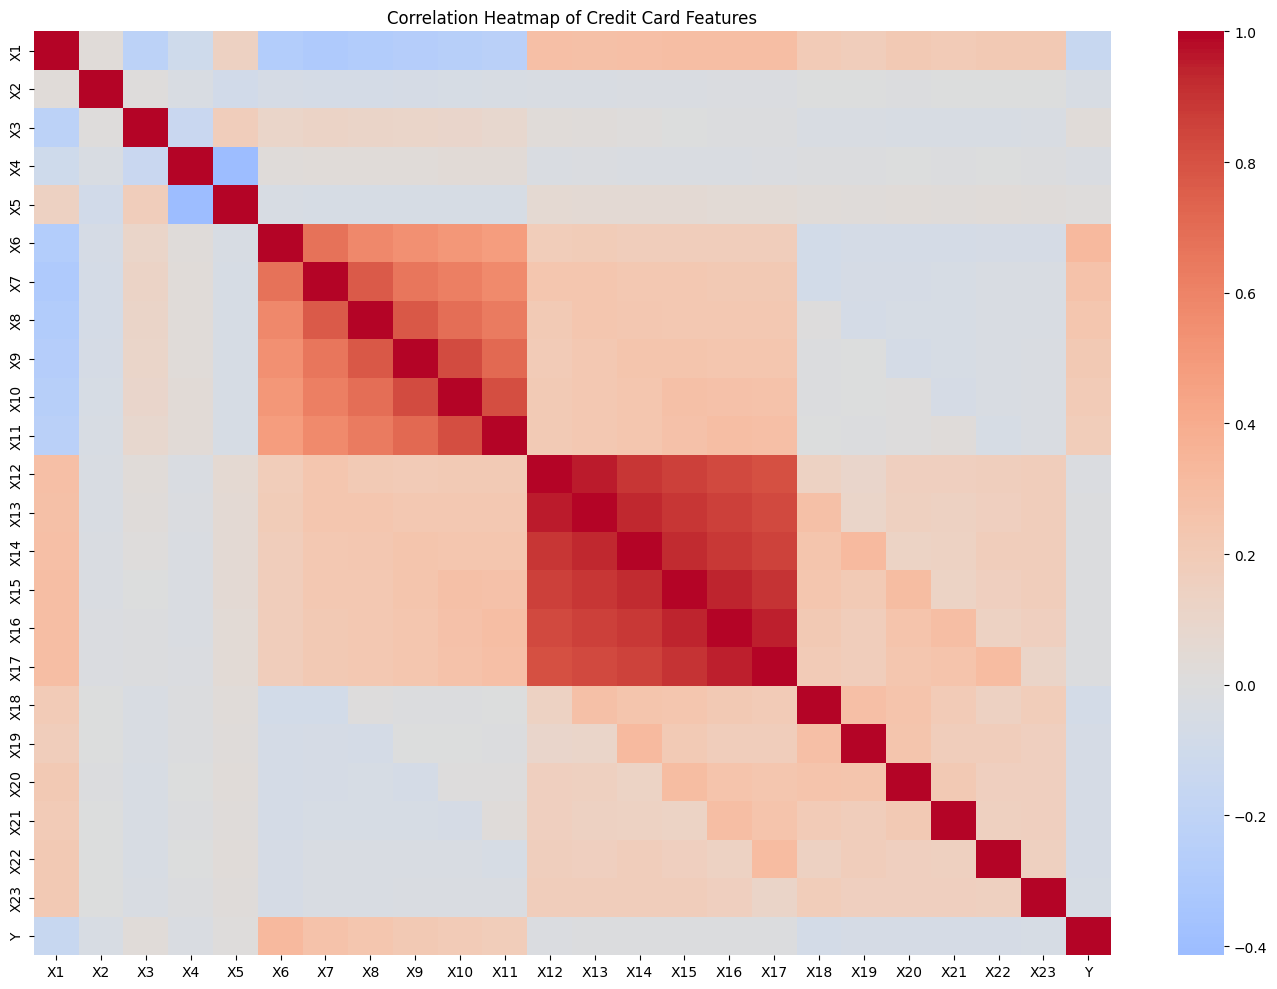

In [49]:
plt.figure(figsize=(14, 10))

correlation = df.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Heatmap of Credit Card Features")
plt.tight_layout()
plt.show()

### Observation

The heatmap shows relationships among the numerical variables. The bill amount and payment amount features show relationships across different months because they represent related financial behaviour.

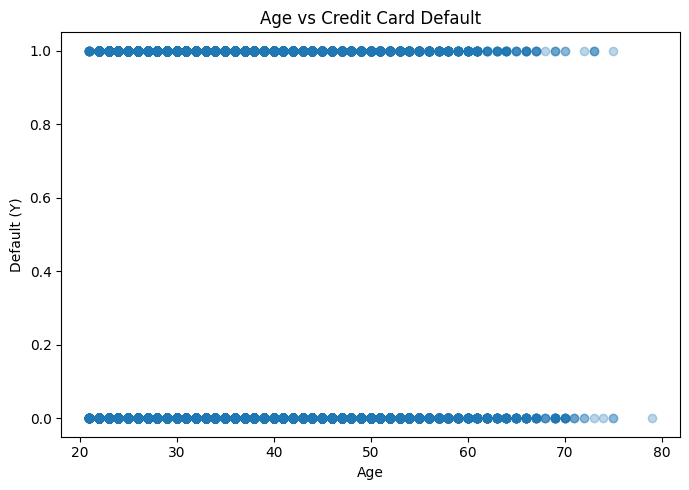

In [50]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["X5"],
    df["Y"],
    alpha=0.3
)

plt.title("Age vs Credit Card Default")
plt.xlabel("Age")
plt.ylabel("Default (Y)")

plt.tight_layout()
plt.show()

### Observation

The plot shows considerable overlap between the default and non-default classes across different ages, indicating that age alone does not clearly separate the two classes.

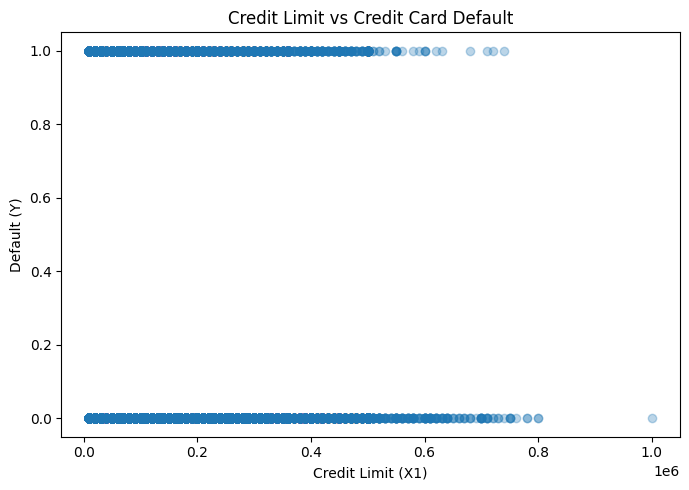

In [51]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["X1"],
    df["Y"],
    alpha=0.3
)

plt.title("Credit Limit vs Credit Card Default")
plt.xlabel("Credit Limit (X1)")
plt.ylabel("Default (Y)")

plt.tight_layout()
plt.show()

### Observation

The plot shows overlap between default and non-default customers across different credit limits, indicating that credit limit alone is not sufficient to distinguish the target classes.

## Outlier Analysis

Outliers are checked in continuous numerical features using the Interquartile Range (IQR) method.

In [52]:
continuous_features = [
    "X1", "X5",
    "X12", "X13", "X14", "X15", "X16", "X17",
    "X18", "X19", "X20", "X21", "X22", "X23"
]

outlier_counts = {}

for col in continuous_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_counts[col] = (
        (df[col] < lower) | (df[col] > upper)
    ).sum()

print("Number of outliers in each feature:")
print(pd.Series(outlier_counts))

Number of outliers in each feature:
X1      167
X5      272
X12    2386
X13    2390
X14    2469
X15    2616
X16    2724
X17    2688
X18    2742
X19    2723
X20    2596
X21    2993
X22    2944
X23    2960
dtype: int64


## Feature Engineering

Two aggregate features are created to summarize the customer's billing and payment behaviour across the six available months.

In [53]:
bill_features = [
    "X12", "X13", "X14",
    "X15", "X16", "X17"
]

payment_features = [
    "X18", "X19", "X20",
    "X21", "X22", "X23"
]

df["Avg_Bill_Amount"] = df[bill_features].mean(axis=1)

df["Avg_Payment_Amount"] = df[payment_features].mean(axis=1)

print("New features created successfully!")

display(
    df[
        ["Avg_Bill_Amount", "Avg_Payment_Amount"]
    ].head()
)

New features created successfully!


,Avg_Bill_Amount,Avg_Payment_Amount
0,1284.000000,114.833333
1,2846.166667,833.333333
2,16942.166667,1836.333333
3,38555.666667,1398.000000
4,18223.166667,9841.500000


### Feature Engineering Justification

Avg_Bill_Amount represents the average bill amount across six months, while Avg_Payment_Amount represents the average payment amount across six months.

These features summarize the customer's overall billing and payment behaviour and may provide useful information for predicting credit card default.

## Separating Features and Target

The input features are separated from the target variable before model training.

In [54]:
X = df.drop(columns=["Y"])
y = df["Y"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (29965, 25)
Target shape: (29965,)


## Stratified Train-Test Split

The dataset is divided into training and testing sets using an 80:20 split. Stratification is used to preserve the target class distribution in both sets.

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (23972, 25)
Testing set: (5993, 25)

Training target distribution:
Y
0    0.778742
1    0.221258
Name: proportion, dtype: float64

Testing target distribution:
Y
0    0.778742
1    0.221258
Name: proportion, dtype: float64


## Outlier Treatment

Extreme values in continuous features are capped using the 1st and 99th percentiles. The limits are calculated using the training set and then applied to both training and testing data.

In [56]:
outlier_lower = {}
outlier_upper = {}

for col in continuous_features:
    outlier_lower[col] = X_train[col].quantile(0.01)
    outlier_upper[col] = X_train[col].quantile(0.99)

X_train = X_train.copy()
X_test = X_test.copy()

for col in continuous_features:
    X_train[col] = X_train[col].clip(
        lower=outlier_lower[col],
        upper=outlier_upper[col]
    )

    X_test[col] = X_test[col].clip(
        lower=outlier_lower[col],
        upper=outlier_upper[col]
    )

print("Outlier treatment completed using training-set 1st and 99th percentile limits.")

Outlier treatment completed using training-set 1st and 99th percentile limits.


## Categorical Encoding and Feature Scaling

Categorical features are one-hot encoded, while numerical features are standardized using StandardScaler.

The preprocessing transformer is fitted only on the training data and then applied to the testing data.

In [57]:
categorical_features = ["X2", "X3", "X4"]

numerical_features = [
    "X1", "X5",
    "X6", "X7", "X8", "X9", "X10", "X11",
    "X12", "X13", "X14", "X15", "X16", "X17",
    "X18", "X19", "X20", "X21", "X22", "X23",
    "Avg_Bill_Amount",
    "Avg_Payment_Amount"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully!")
print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Preprocessing completed successfully!
Training shape: (23972, 35)
Testing shape: (5993, 35)


## Classification Part A

### 1. Logistic Regression

Logistic Regression is used as a baseline classification model for predicting whether a customer will default.

In [58]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

y_pred_lr = logistic_model.predict(X_test_processed)

y_prob_lr = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

print("Logistic Regression completed!")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("Weighted F1-score:", f1_score(y_test, y_pred_lr, average="weighted"))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression completed!
Accuracy: 0.8134490238611713
Precision: 0.7251082251082251
Recall: 0.2526395173453997
Weighted F1-score: 0.776278836828978
ROC-AUC: 0.7233717307199454


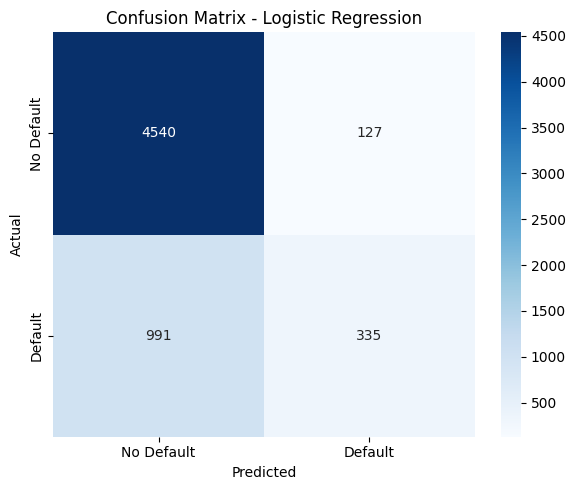

In [59]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### 2. K-Nearest Neighbors (KNN)

KNN classifies a customer based on the classes of nearby observations. Feature scaling is important because KNN uses distances between observations.

In [60]:
# KNN Hyperparameter Tuning

knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11, 15]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring="f1_weighted"
)

knn_grid.fit(
    X_train_processed,
    y_train
)

# Best KNN model
knn_model = knn_grid.best_estimator_

print("Best KNN Parameters:", knn_grid.best_params_)

# Predictions
y_pred_knn = knn_model.predict(
    X_test_processed
)

# Probability for ROC-AUC
y_prob_knn = knn_model.predict_proba(
    X_test_processed
)[:, 1]

# Evaluation
print("KNN completed!")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("Weighted F1-score:", f1_score(y_test, y_pred_knn, average="weighted"))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))

Best KNN Parameters: {'n_neighbors': 15}
KNN completed!
Accuracy: 0.8082763223761055
Precision: 0.6224066390041494
Recall: 0.3393665158371041
Weighted F1-score: 0.7858822683725925
ROC-AUC: 0.7388503439153182


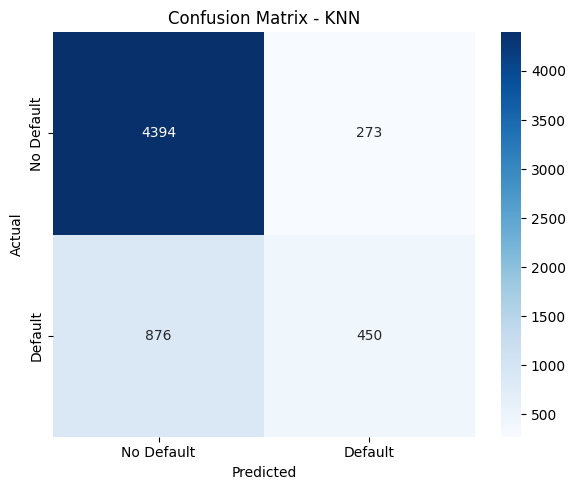

In [61]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### 3. Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classifier based on Bayes' theorem and assumes conditional independence between features.

In [22]:
nb_model = GaussianNB()

nb_model.fit(
    X_train_processed,
    y_train
)

y_pred_nb = nb_model.predict(
    X_test_processed
)

y_prob_nb = nb_model.predict_proba(
    X_test_processed
)[:, 1]

print("Gaussian Naive Bayes completed!")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("Weighted F1-score:", f1_score(y_test, y_pred_nb, average="weighted"))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nb))

Gaussian Naive Bayes completed!
Accuracy: 0.3220423827799099
Precision: 0.23748321503932476
Recall: 0.9336349924585219
Weighted F1-score: 0.2816461361211992
ROC-AUC: 0.7244743507331893


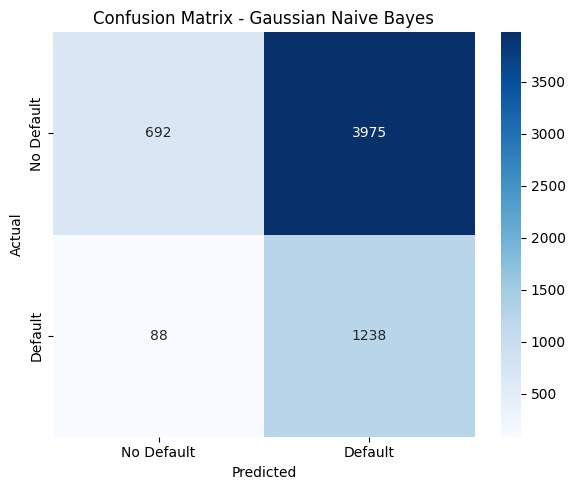

In [62]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### 4. Decision Tree Classifier

Decision Tree Classifier predicts the target by creating a sequence of decision rules based on the input features.

In [63]:
# Decision Tree Hyperparameter Tuning

dt_params = {
    "max_depth": [3, 5, 7, 10, 15, None]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring="f1_weighted"
)

dt_grid.fit(
    X_train_processed,
    y_train
)

# Best Decision Tree model
dt_model = dt_grid.best_estimator_

print("Best Decision Tree Parameters:", dt_grid.best_params_)

# Predictions
y_pred_dt = dt_model.predict(
    X_test_processed
)

# Probability for ROC-AUC
y_prob_dt = dt_model.predict_proba(
    X_test_processed
)[:, 1]

# Evaluation
print("Decision Tree completed!")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("Weighted F1-score:", f1_score(y_test, y_pred_dt, average="weighted"))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

Best Decision Tree Parameters: {'max_depth': 5}
Decision Tree completed!
Accuracy: 0.8172868346404139
Precision: 0.6517739816031537
Recall: 0.3740573152337858
Weighted F1-score: 0.7977687698670646
ROC-AUC: 0.7446439669306103


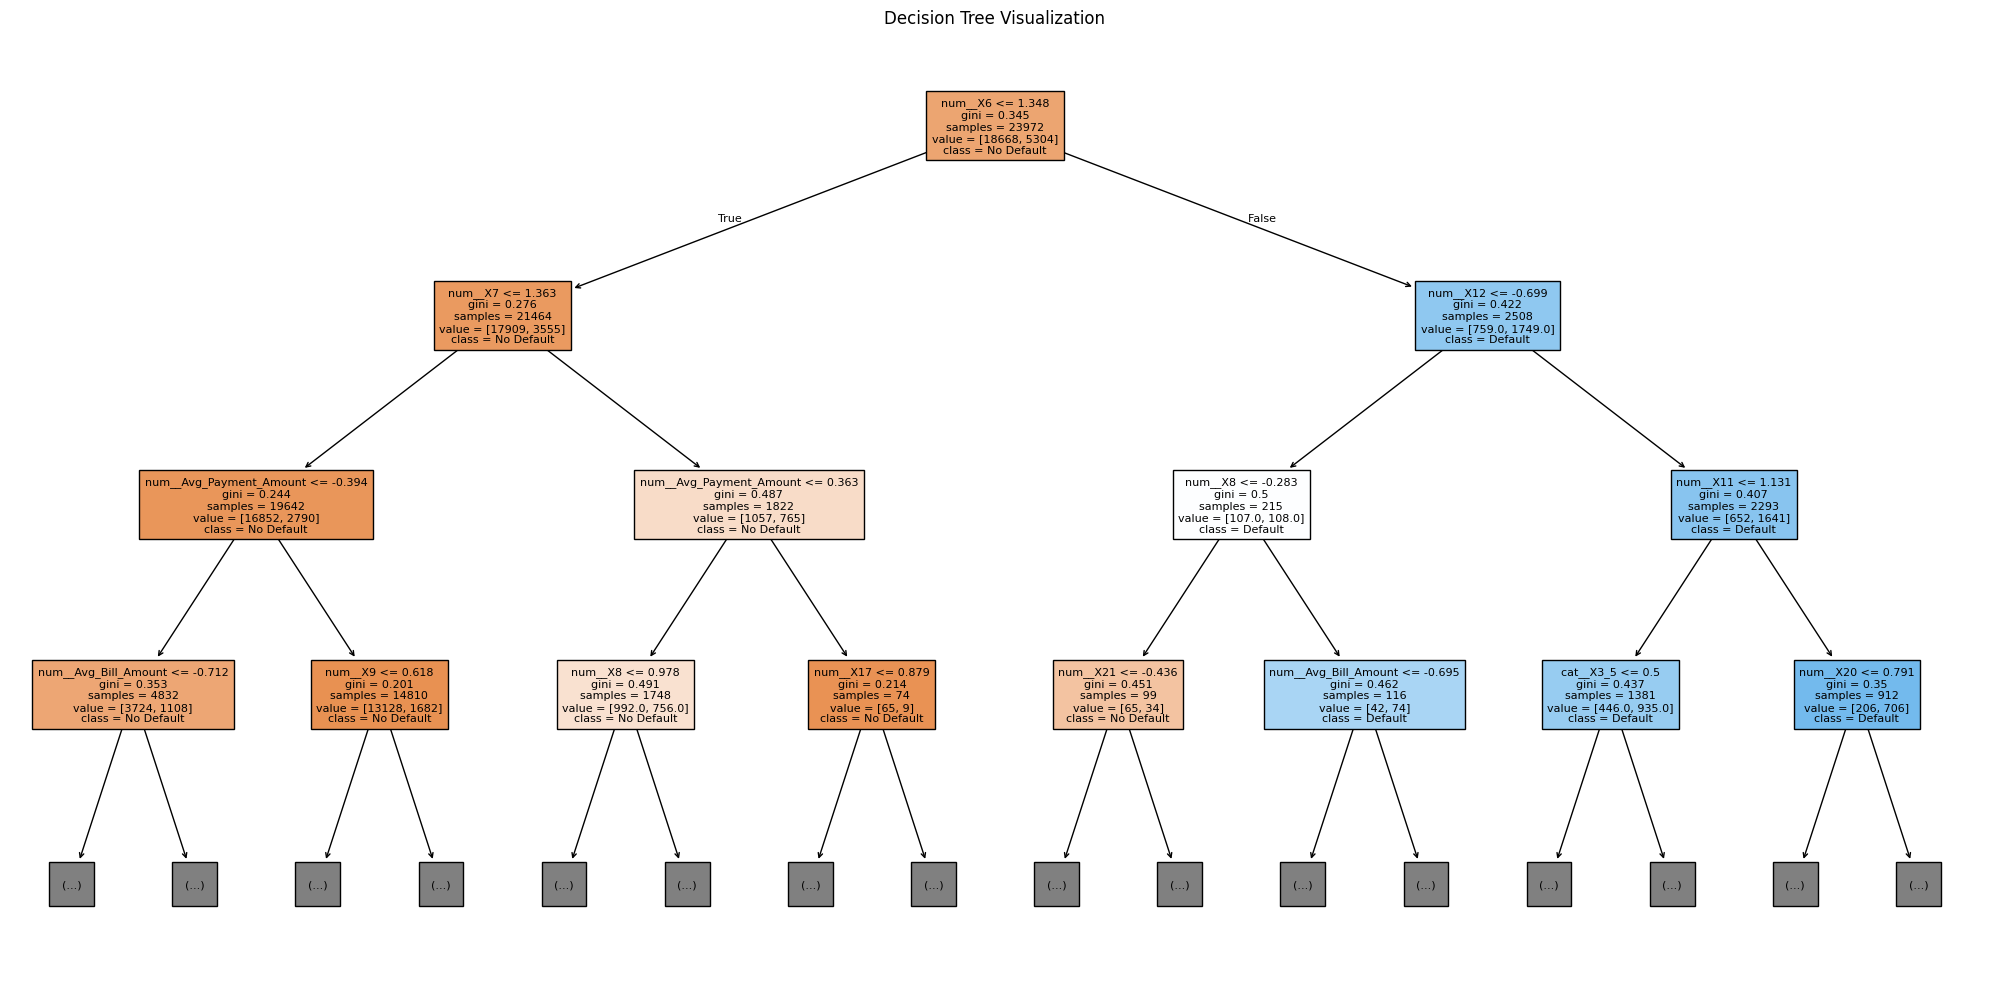

In [64]:
# Decision Tree Visualization

from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    max_depth=3,
    filled=True,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=["No Default", "Default"],
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.tight_layout()
plt.show()

### Decision Tree Confusion Matrix

The confusion matrix shows the correct and incorrect predictions made by the Decision Tree classifier for the two classes: No Default and Default.

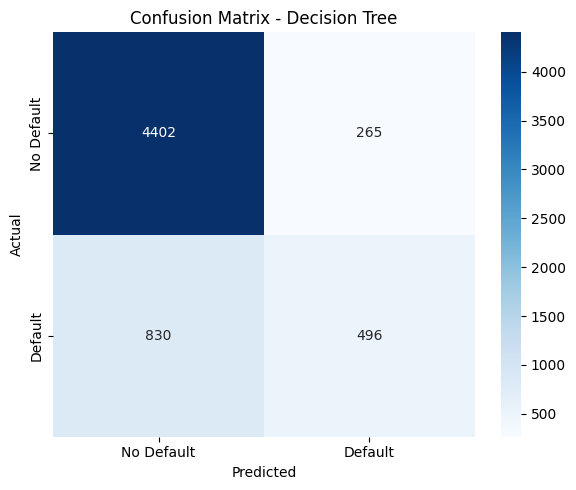

In [65]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### 5. Support Vector Machine (SVM)

SVM is a classification algorithm that finds a decision boundary that separates the classes. The features are scaled before applying SVM.

SVM Results
-------------------------
Accuracy: 0.8091106290672451
Precision: 0.6986899563318777
Recall: 0.24132730015082957
Weighted F1-score: 0.7707928588750064
ROC-AUC: 0.691483413757453


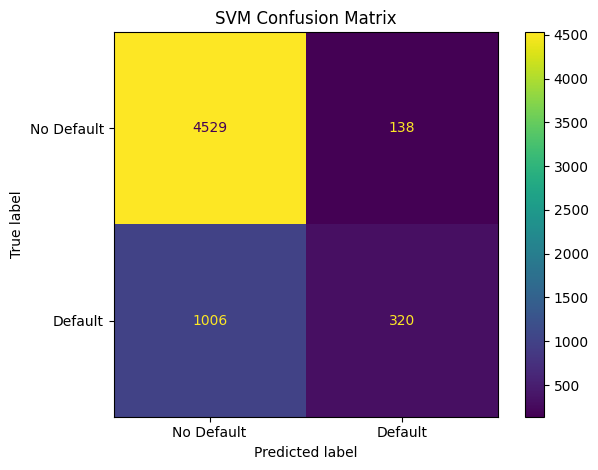

In [66]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Create SVM model
svm_model = SVC(
    C=1,
    kernel="linear",
    random_state=42
)

# Train
svm_model.fit(X_train_processed, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test_processed)

# Evaluation
print("SVM Results")
print("-------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_svm, zero_division=0))
print(
    "Weighted F1-score:",
    f1_score(y_test, y_pred_svm, average="weighted", zero_division=0)
)

# ROC-AUC
y_score_svm = svm_model.decision_function(X_test_processed)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_score_svm)
)

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["No Default", "Default"]
)

disp.plot()
plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()

### SVM Hyperparameter Tuning

The SVM hyperparameters C and kernel were tuned using a validation subset of the training data. Different combinations of C values (0.1, 1, 10) and kernels (linear and RBF) were compared using validation accuracy. The selected parameters were then used to train the final SVM model.

In [67]:
# SVM Hyperparameter Tuning: C and Kernel

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# Use a small sample only for tuning
X_tune = X_train_processed[:1000]
y_tune = y_train[:1000]

# Split tuning data into training and validation sets
X_tune_train, X_tune_val, y_tune_train, y_tune_val = train_test_split(
    X_tune,
    y_tune,
    test_size=0.2,
    stratify=y_tune,
    random_state=42
)

C_values = [0.1, 1, 10]
kernel_values = ['linear', 'rbf']

svc_tuning_results = []

for C in C_values:
    for kernel in kernel_values:

        svc_model_temp = SVC(
            C=C,
            kernel=kernel,
            random_state=42
        )

        svc_model_temp.fit(
            X_tune_train,
            y_tune_train
        )

        y_pred = svc_model_temp.predict(X_tune_val)

        accuracy = accuracy_score(
            y_tune_val,
            y_pred
        )

        svc_tuning_results.append({
            'C': C,
            'Kernel': kernel,
            'Validation Accuracy': accuracy
        })

svc_tuning_df = pd.DataFrame(svc_tuning_results)

svc_tuning_df

,C,Kernel,Validation Accuracy
0,0.1,linear,0.855
1,0.1,rbf,0.760
2,1.0,linear,0.855
3,1.0,rbf,0.840
4,10.0,linear,0.855
5,10.0,rbf,0.805


In [68]:
# Final Tuned SVM Model

from sklearn.svm import SVC

# Select the best C and kernel based on validation accuracy
best_svc_row = svc_tuning_df.loc[
    svc_tuning_df["Validation Accuracy"].idxmax()
]

best_C = best_svc_row["C"]
best_kernel = best_svc_row["Kernel"]

print("Best SVM Parameters")
print("-------------------------")
print("C:", best_C)
print("Kernel:", best_kernel)
print("Validation Accuracy:", best_svc_row["Validation Accuracy"])

# Train final SVM using the best parameters
svm_tuned = SVC(
    C=best_C,
    kernel=best_kernel,
    random_state=42
)

svm_tuned.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_svm_tuned = svm_tuned.predict(
    X_test_processed
)

# Decision scores for ROC-AUC
y_score_svm_tuned = svm_tuned.decision_function(
    X_test_processed
)

print("\nFinal Tuned SVM trained successfully!")

Best SVM Parameters
-------------------------
C: 0.1
Kernel: linear
Validation Accuracy: 0.855

Final Tuned SVM trained successfully!


## Comparison of Classification Part A Models

The five Classification Part A algorithms were evaluated using the same training and testing datasets and the same preprocessing pipeline.

The models are compared using Accuracy, Precision, Recall, Weighted F1-score, and ROC-AUC. A summary table is presented below to compare the performance of all five algorithms.

In [69]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Gaussian Naive Bayes",
        "Decision Tree",
        "SVM"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_svm_tuned)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_knn, zero_division=0),
        precision_score(y_test, y_pred_nb, zero_division=0),
        precision_score(y_test, y_pred_dt, zero_division=0),
        precision_score(y_test, y_pred_svm_tuned, zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_knn, zero_division=0),
        recall_score(y_test, y_pred_nb, zero_division=0),
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_svm_tuned, zero_division=0)
    ],

    "Weighted F1": [
        f1_score(y_test, y_pred_lr, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_knn, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_nb, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_dt, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_svm_tuned, average="weighted", zero_division=0)
    ],

    "ROC-AUC": [
        roc_auc_score(
            y_test,
            logistic_model.predict_proba(X_test_processed)[:, 1]
        ),
        roc_auc_score(
            y_test,
            knn_model.predict_proba(X_test_processed)[:, 1]
        ),
        roc_auc_score(
            y_test,
            nb_model.predict_proba(X_test_processed)[:, 1]
        ),
        roc_auc_score(
            y_test,
            dt_model.predict_proba(X_test_processed)[:, 1]
        ),
        roc_auc_score(
            y_test,
            y_score_svm_tuned
        )
    ]
})

comparison_df.round(4)

,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,Logistic Regression,0.8134,0.7251,0.2526,0.7763,0.7234
1,KNN,0.8083,0.6224,0.3394,0.7859,0.7389
2,Gaussian Naive Bayes,0.3220,0.2375,0.9336,0.2816,0.7245
3,Decision Tree,0.8173,0.6518,0.3741,0.7978,0.7446
4,SVM,0.8089,0.6972,0.2413,0.7707,0.6989


###  Preliminary Model Comparison

The five Classification Part A models are compared using **Accuracy** and **Weighted F1-score**. Confusion matrices are also provided for each model to examine the classification results across the classes.

The comparison provides a preliminary evaluation of the performance of Logistic Regression, KNN, Gaussian Naive Bayes, Decision Tree, and the tuned SVM model.


In [70]:
# Review 1 D2 - Preliminary Classification Comparison

d2_comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Gaussian Naive Bayes",
        "Decision Tree",
        "SVM"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_svm_tuned)
    ],

    "Weighted F1": [
        f1_score(y_test, y_pred_lr, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_knn, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_nb, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_dt, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_svm_tuned, average="weighted", zero_division=0)
    ],

    "Confusion Matrix": [
        str(confusion_matrix(y_test, y_pred_lr)),
        str(confusion_matrix(y_test, y_pred_knn)),
        str(confusion_matrix(y_test, y_pred_nb)),
        str(confusion_matrix(y_test, y_pred_dt)),
        str(confusion_matrix(y_test, y_pred_svm_tuned))
    ]
})

d2_comparison_df.round(4)

,Model,Accuracy,Weighted F1,Confusion Matrix
0,Logistic Regression,0.8134,0.7763,[[4540 127]\n [ 991 335]]
1,KNN,0.8083,0.7859,[[4394 273]\n [ 876 450]]
2,Gaussian Naive Bayes,0.3220,0.2816,[[ 692 3975]\n [ 88 1238]]
3,Decision Tree,0.8173,0.7978,[[4402 265]\n [ 830 496]]
4,SVM,0.8089,0.7707,[[4528 139]\n [1006 320]]


## Visual Comparison of Classification Models

The performance of the five Classification Part A models is compared visually using Accuracy, Precision, Recall, Weighted F1-score, and ROC-AUC. This visualization helps compare the models across the different evaluation metrics.

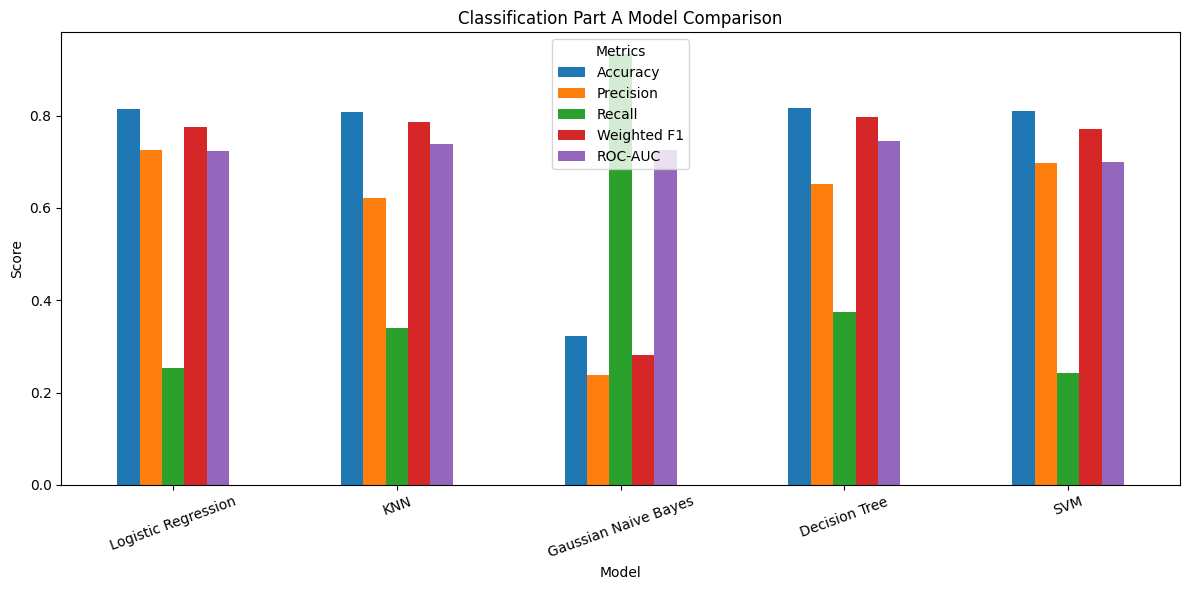

In [71]:
comparison_plot = comparison_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "Weighted F1", "ROC-AUC"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Classification Part A Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

## 5-Fold Cross-Validation

To assess the stability and generalization performance of the classification models, 5-fold cross-validation was performed on the two selected models: Decision Tree and K-Nearest Neighbors (KNN).

The **weighted F1-score** was used as the evaluation metric. The mean weighted F1-score represents the average performance across the five folds, while the standard deviation indicates the variation in performance between folds.

The cross-validation results are presented below for comparison.


In [72]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross-Validation for Decision Tree
dt_cv_scores = cross_val_score(
    dt_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="f1_weighted"
)

# 5-Fold Cross-Validation for KNN
knn_cv_scores = cross_val_score(
    knn_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="f1_weighted"
)

cv_results = pd.DataFrame({
    "Model": ["Decision Tree", "KNN"],
    "Mean CV Weighted F1": [
        dt_cv_scores.mean(),
        knn_cv_scores.mean()
    ],
    "Std CV Weighted F1": [
        dt_cv_scores.std(),
        knn_cv_scores.std()
    ]
})

cv_results.round(4)

,Model,Mean CV Weighted F1,Std CV Weighted F1
0,Decision Tree,0.7978,0.006
1,KNN,0.7872,0.006


## Conclusion

The five Classification Part A algorithms were successfully implemented and evaluated on the same test dataset. Their performance was compared using Accuracy, Precision, Recall, Weighted F1-score, and ROC-AUC.

The confusion matrices and comparison visualization provide an overall view of the classification performance. The results from this stage will serve as the baseline for further classification work in Review 2.

## End of Classification Part A

Classification Part A is complete with all five required algorithms, their evaluation metrics, confusion matrices, and the preliminary model comparison.